In [ ]:
!pip install -q tensorflow numpy matplotlib seaborn scikit-learn

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dropout, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import os
import shutil
import zipfile

In [ ]:
# Upload your kaggle.json API token
from google.colab import files
files.upload()

# Set up Kaggle directory and permissions
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

Saving kaggle.json to kaggle (1).json


In [ ]:
!kaggle datasets download -d emmarex/plantdisease
!unzip -q plantdisease.zip -d plant_disease

Dataset URL: https://www.kaggle.com/datasets/emmarex/plantdisease
License(s): unknown
100% 656M/658M [00:01<00:00, 296MB/s]
100% 658M/658M [00:01<00:00, 395MB/s]


In [ ]:
# Define source and destination directories
# This is the correct path, as Linux is case-sensitive
source_dir = 'plant_disease/PlantVillage'
dest_dir = 'tomato_dataset_filtered'

# Create the new directory
os.makedirs(dest_dir, exist_ok=True)

print(f"Copying Tomato classes from {source_dir} to {dest_dir}...")

# Iterate over all folders in the source directory
for class_folder in os.listdir(source_dir):
    # Check if the folder is a "Tomato" class
    if class_folder.startswith('Tomato__'):
        source_class_path = os.path.join(source_dir, class_folder)
        dest_class_path = os.path.join(dest_dir, class_folder)

        # Copy the entire folder
        if not os.path.exists(dest_class_path):
            shutil.copytree(source_class_path, dest_class_path)
            print(f"Copied: {class_folder}")

print("Finished filtering for tomato diseases.")

Copying Tomato classes from plant_disease/PlantVillage to tomato_dataset_filtered...
Copied: Tomato__Target_Spot
Copied: Tomato__Tomato_mosaic_virus
Copied: Tomato__Tomato_YellowLeaf__Curl_Virus
Finished filtering for tomato diseases.


In [ ]:
#part5
# Install split-folders if not already installed
!pip install -q split-folders

import splitfolders  # <-- this import was missing

input_folder = 'tomato_dataset_filtered'
output_folder = 'tomato_dataset_split'

# Split with a ratio of 80% train, 10% validation, 10% test
# The 'seed' makes sure the split is the same every time you run it
print(f"Splitting data from {input_folder} into {output_folder}...")

splitfolders.ratio(input_folder,
                   output=output_folder,
                   seed=42,
                   ratio=(.8, .1, .1), # 80% train, 10% val, 10% test
                   group_prefix=None)

print("Splitting complete.")


Splitting data from tomato_dataset_filtered into tomato_dataset_split...


Copying files: 4986 files [00:00, 9019.28 files/s]

Splitting complete.


In [ ]:
# Define image size and batch size
IMG_WIDTH, IMG_HEIGHT = 224, 224
BATCH_SIZE = 32
IMG_SHAPE = (IMG_WIDTH, IMG_HEIGHT, 3)

# Define paths to our new SPLIT dataset
base_split_dir = 'tomato_dataset_split'
train_dir = os.path.join(base_split_dir, 'train')
val_dir = os.path.join(base_split_dir, 'val') # split-folders names it 'val'
test_dir = os.path.join(base_split_dir, 'test')

# 1. Training Data Generator (with Augmentation)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# 2. Validation & Test Data Generator (only rescale)
validation_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)


# Create the generators from our directories
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

validation_generator = validation_datagen.flow_from_directory(
    val_dir,
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# Get class names and number of classes
class_names = list(train_generator.class_indices.keys())
num_classes = len(class_names)
print(f"Found {num_classes} classes: {class_names}")

Found 3987 images belonging to 3 classes.
Found 497 images belonging to 3 classes.
Found 501 images belonging to 3 classes.
Found 3 classes: ['Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus']


In [ ]:
# 1. Load the pre-trained base model (MobileNetV2)
base_model = MobileNetV2(input_shape=IMG_SHAPE,
                         include_top=False,  # Do not include the final ImageNet classifier
                         weights='imagenet')

# 2. Freeze the base model
base_model.trainable = False

# 3. Create our new model on top
inputs = Input(shape=IMG_SHAPE)
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
outputs = Dense(num_classes, activation='softmax')(x)

# 4. Define the full model
model = Model(inputs, outputs)

# Print the model summary
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │         3,843 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,261,827 (8.63 MB)

 Trainable params: 3,843 (15.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
EPOCHS = 20

history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // BATCH_SIZE
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 80s 508ms/step - accuracy: 0.7542 - loss: 0.6103 - val_accuracy: 0.9438 - val_loss: 0.1497
Epoch 2/20
  1/124 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.8750 - loss: 0.2777

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8750 - loss: 0.2777 - val_accuracy: 0.9438 - val_loss: 0.1491
Epoch 3/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 48s 384ms/step - accuracy: 0.9270 - loss: 0.1983 - val_accuracy: 0.9646 - val_loss: 0.0950
Epoch 4/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9375 - loss: 0.2318 - val_accuracy: 0.9667 - val_loss: 0.0949
Epoch 5/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 47s 378ms/step - accuracy: 0.9426 - loss: 0.1547 - val_accuracy: 0.9812 - val_loss: 0.0670
Epoch 6/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9375 - loss: 0.1546 - val_accuracy: 0.9812 - val_loss: 0.0665
Epoch 7/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 82s 662ms/step - accuracy: 0.9561 - loss: 0.1301 - val_accuracy: 0.9792 - val_loss: 0.0569
Epoch 8/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9062 - loss: 0.2702 - val_accuracy: 0.9792 - val_loss: 0.0574
Epoch 9/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 82s 663ms/step - accuracy: 0.9675 - loss: 0.1044 - val_accuracy: 0

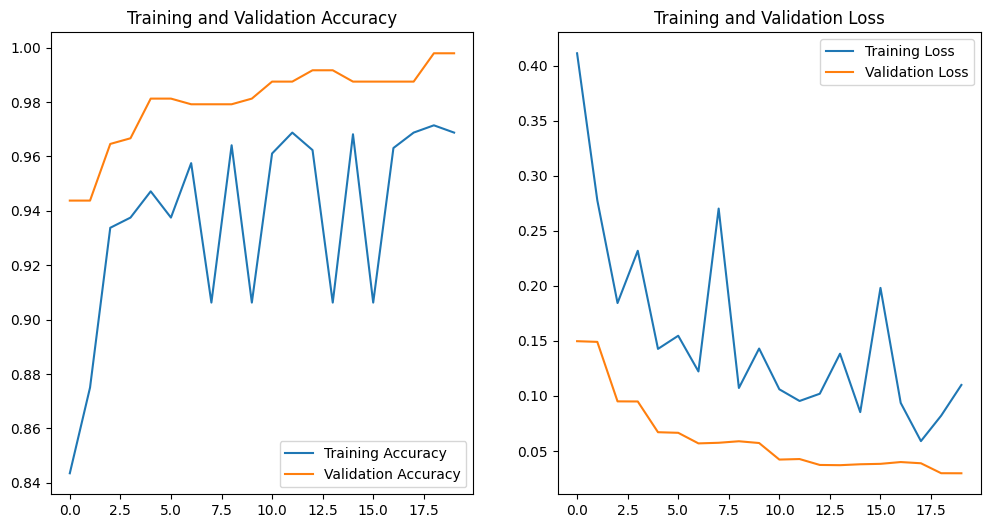

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(EPOCHS)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [ ]:
#fine tunning
# Unfreeze the base model
base_model.trainable = True

# Let's freeze the bottom layers and only train the top ones
fine_tune_at = 100

# Freeze all layers before the `fine_tune_at` layer
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# Compile again with a much lower learning rate (validation matrix)
model.compile(loss='categorical_crossentropy',
              optimizer=Adam(learning_rate=1e-5),
              metrics=['accuracy'])

# Continue training (fine-tuning)
fine_tune_epochs = 10
total_epochs = EPOCHS + fine_tune_epochs

history_fine = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    epochs=total_epochs,
    initial_epoch=history.epoch[-1],
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // BATCH_SIZE
)

Epoch 20/30
124/124 ━━━━━━━━━━━━━━━━━━━━ 84s 505ms/step - accuracy: 0.9040 - loss: 0.3013 - val_accuracy: 0.9792 - val_loss: 0.0552
Epoch 21/30
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 1.0000 - loss: 0.0426 - val_accuracy: 0.9792 - val_loss: 0.0553
Epoch 22/30
124/124 ━━━━━━━━━━━━━━━━━━━━ 82s 663ms/step - accuracy: 0.9485 - loss: 0.1608 - val_accuracy: 0.9500 - val_loss: 0.0973
Epoch 23/30
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 1.0000 - loss: 0.0609 - val_accuracy: 0.9500 - val_loss: 0.0978
Epoch 24/30
124/124 ━━━━━━━━━━━━━━━━━━━━ 142s 670ms/step - accuracy: 0.9543 - loss: 0.1366 - val_accuracy: 0.9292 - val_loss: 0.1437
Epoch 25/30
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9688 - loss: 0.0594 - val_accuracy: 0.9292 - val_loss: 0.1434
Epoch 26/30
124/124 ━━━━━━━━━━━━━━━━━━━━ 47s 377ms/step - accuracy: 0.9628 - loss: 0.1174 - val_accuracy: 0.9229 - val_loss: 0.1638
Epoch 27/30
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9688 - loss: 0.02

--- Evaluating Model on Test Set ---
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.9305 - loss: 0.2724
Test Loss: 0.14216654002666473
Test Accuracy: 0.9583333134651184
16/16 ━━━━━━━━━━━━━━━━━━━━ 17s 804ms/step

--- Classification Report ---
                                       precision    recall  f1-score   support

                  Tomato__Target_Spot       1.00      0.89      0.94       141
Tomato__Tomato_YellowLeaf__Curl_Virus       0.99      0.98      0.99       322
          Tomato__Tomato_mosaic_virus       0.69      1.00      0.82        38

                             accuracy                           0.96       501
                            macro avg       0.89      0.96      0.92       501
                         weighted avg       0.97      0.96      0.96       501


--- Confusion Matrix ---


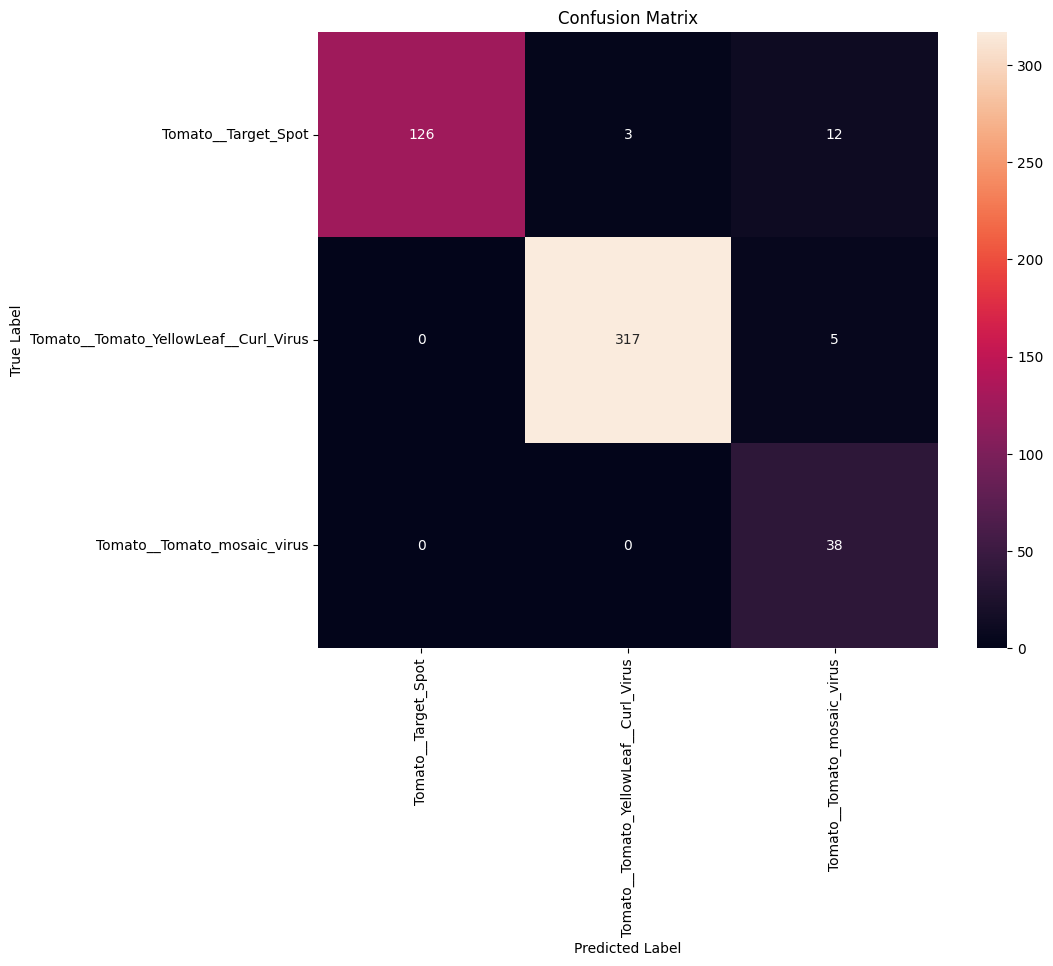

In [ ]:
# 1. Evaluate on the test set
print("--- Evaluating Model on Test Set ---")
test_loss, test_accuracy = model.evaluate(test_generator, steps=test_generator.samples // BATCH_SIZE)
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")

# 2. Get predictions for the entire test set
test_generator.reset()
predictions = model.predict(test_generator, steps=test_generator.samples // BATCH_SIZE + 1)
predicted_classes = np.argmax(predictions, axis=1)

# 3. Get true labels
true_classes = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

# 4. Print Classification Report
print("\n--- Classification Report ---")
# Ensure true_classes and predicted_classes are the same length
if len(predicted_classes) > len(true_classes):
    predicted_classes = predicted_classes[:len(true_classes)]

print(classification_report(true_classes, predicted_classes, target_names=class_labels))

# 5. Display Confusion Matrix
print("\n--- Confusion Matrix ---")
cm = confusion_matrix(true_classes, predicted_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

In [ ]:
# Save the model
model.save('tomato_disease_detection_model.h5')
print("Model saved as 'tomato_disease_detection_model.h5'")

# You can download it from the Colab file explorer (left-hand side)

Model saved as 'tomato_disease_detection_model.h5'
